# Ablation Study : RAG baseline vs LightRAG hybride vs Agentic GraphRAG

**PFE Agentic GraphRAG — Wiame Anejjar — Master SDIA 2025-2026**

## Objectif

Isoler la contribution de chaque couche de l'architecture en évaluant **trois systèmes** sur le **même benchmark**, avec le **même LLM générateur** et les **mêmes métriques RAGAS** :

1. **RAG vectoriel (ChromaDB seul)** — aucun graphe, retrieval par similarité vectorielle uniquement.
2. **LightRAG hybride (sans agent)** — retrieval graphe + vecteurs de LightRAG (mode hybrid), une seule génération, sans boucle de correction.
3. **Agentic GraphRAG (contribution du PFE)** — même retrieval LightRAG que (2), plus la boucle CRITIQUE → SELF_CORRECT avec juge indépendant.

La seule variable qui change entre (2) et (3) est la présence de la couche agentique : cela permet de mesurer sa contribution propre, isolée du choix du backend de retrieval.

**Benchmark utilisé** : `data/processed/benchmark_true_multihop.json` — 76 questions vrai multi-hop, validées par analyse de contenu (voir `scripts/validate_multihop_benchmark.py`), pas par la simple étiquette `hop_type` d'origine.

**Important** : les résultats de ce notebook sont ceux effectivement obtenus à l'exécution , aucun chiffre n'est pré-rempli ou supposé à l'avance.

In [1]:
import os, sys, json, random, asyncio, time, datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import nest_asyncio
nest_asyncio.apply()

from dotenv import load_dotenv
load_dotenv()

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
pd.set_option("display.max_colwidth", 120)
print(f"Notebook exécuté le : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook exécuté le : 2026-08-05 15:01:56


## 1. Chargement du benchmark

In [2]:
BENCHMARK_PATH = Path("data/processed/benchmark_true_multihop.json")
# Recommandation prof du 30/07 : passer a 30 questions, avec checkpointing +
# rotation de cles Groq (GROQ_API_KEY/_2/_3, cf. section 2bis) pour tenir
# malgre le quota gratuit Groq -> plus besoin de reduire l'echelle.
N_QUESTIONS = int(os.getenv("EVAL_N_QUESTIONS", "30"))
SEED = 42

with BENCHMARK_PATH.open("r", encoding="utf-8") as f:
    all_items = json.load(f)

random.seed(SEED)
eval_items = random.sample(all_items, min(N_QUESTIONS, len(all_items)))

print(f"Benchmark source                     : {BENCHMARK_PATH}")
print(f"Questions vrai multi-hop disponibles  : {len(all_items)}")
print(f"Questions échantillonnées (seed={SEED})    : {len(eval_items)}")

display(pd.DataFrame([
    {"question": it["question"], "ground_truth": it["ground_truth"]}
    for it in eval_items
]))

Benchmark source                     : data\processed\benchmark_true_multihop.json
Questions vrai multi-hop disponibles  : 76
Questions échantillonnées (seed=42)    : 30


,question,ground_truth
0,"What type of knowledge graph model is used to represent context-dependent triplet validity, which is developed from ...",Quantum Knowledge Graph
1,What method is designed to improve defenses against the type of models that often rely on the Model Context Protocol...,Autorise Method
2,"What system is built on Gemini 2.5 Flash, which exhibits a lower but still significant individualism-collectivism bi...",Itas
3,What type of cultural bias is exhibited by the LLM applied to synthetic patient profiles in reliability auditing?,Western-Style Individualism
4,"What aspect of GPT-5.4 is affected when generic retry is applied to improve its performance, and this model only res...",GPT-5.4's Stated Country Identity
5,What approach is based on the core idea of a learning method that Hindsight Preference Optimization draws from to ge...,Epm-Rl
6,What type of models have shown improved image editing performance by incorporating the method used to solve math pro...,Unified Multi-Modal Understanding/Generative Models
7,What is the application of the method that outperforms UniVL-DR on the WebQA+ and EVQA+ datasets when considering sh...,Target Binding
8,What phenomenon occurs in TTRL as a result of the challenges posed by label noise in medical image classification ad...,Spurious Signal Amplification
9,"What aspect of performance do Vision-Language Models, which utilize Bayesian Inference Module for anomaly localizati...",Temporal Consistency


## 2. Configuration commune (générateur + prompt)

Pour que la comparaison isole bien la variable étudiée (retrieval + boucle agentique), les trois systèmes réutilisent **directement** le générateur et le prompt de `src/agent/graph_v3.py` (fonction `_llm_call`, prompt `RESPONSE_SYSTEM_PROMPT`) — pas une copie séparée. Quel que soit le backend actif (NVIDIA / Groq / Ollama local, contrôlé par les variables d'environnement `USE_NVIDIA`/`USE_GROQ`), les trois systèmes utilisent donc exactement le même LLM pour la génération finale.

Seuls le contexte fourni (retrieval) et la présence ou non de la boucle CRITIQUE/SELF_CORRECT diffèrent entre les trois systèmes.

In [3]:
from langchain_ollama import OllamaEmbeddings

# Réutilise l'infrastructure déjà initialisée dans graph_v3.py (déclenche l'init
# du LLM générateur, du juge et de rag_instance -> un seul point de configuration)
from src.agent import graph_v3

EMBED_MODEL    = os.getenv("EMBED_MODEL", "nomic-embed-text")
OLLAMA_URL     = os.getenv("OLLAMA_URL", "http://localhost:11434")

if graph_v3.USE_NVIDIA and graph_v3.NVIDIA_API_KEY:
    GENERATOR_DESC = f"NVIDIA {graph_v3.NVIDIA_MODEL}"
elif graph_v3.USE_GROQ and graph_v3.GROQ_API_KEY:
    GENERATOR_DESC = f"Groq {graph_v3.GROQ_GENERATOR_MODEL}"
else:
    GENERATOR_DESC = f"Ollama {graph_v3.MODEL_NAME} (num_ctx={graph_v3.OLLAMA_NUM_CTX})"

def generate_answer(question: str, context: str) -> str:
    # Meme troncature defensive que node_response (evite les 413 "request too
    # large" de certains backends, ex. Groq llama-3.1-8b-instant)
    context = context[:graph_v3.MAX_GENERATOR_CONTEXT_CHARS]
    user = f"Context:\n{context}\n\nQuestion: {question}\n\nAnswer (use ONLY the context above, cite sources):"
    return graph_v3._llm_call(graph_v3.RESPONSE_SYSTEM_PROMPT, user)

print(f"Générateur commun (systèmes 1, 2 et 3) : {GENERATOR_DESC}")
print(f"Contexte tronqué à {graph_v3.MAX_GENERATOR_CONTEXT_CHARS} caractères avant génération (anti-413)")

c:\Users\ADMIN\Desktop\PFE_Agentic_Graphrag\GraphRag_PFE\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LLM GENERATOR] Groq llama-3.1-8b-instant
[LLM JUDGE] Groq llama-3.3-70b-versatile (indépendant du générateur)
======= JUDGE STATUS ========== independent=True


INFO: [] Loaded graph from indexes\lightrag_500_connected_v2\graph_chunk_entity_relation.graphml with 4945 nodes, 5593 edges
INFO:nano-vectordb:Load (4980, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_entities.json'} 4980 data
INFO:nano-vectordb:Load (5730, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_relationships.json'} 5730 data
INFO:nano-vectordb:Load (500, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_chunks.json'} 500 data
INFO: [] Process 9608 KV load full_docs with 500 records
INFO: [] Process 9608 KV load text_chunks with 500 records
INFO: [] Process 9608 KV load full_entities with 500 records
INFO: [] Process 9608 KV load full_relations with 5068 records
INFO: [] Process 9608 KV load entity_chunks with 4977 records

[LIGHTRAG] Initialisé → indexes\lightrag_500_connected_v2
Générateur commun (systèmes 1, 2 et 3) : Groq llama-3.1-8b-instant
Contexte tronqué à 8000 caractères avant génération (anti-413)


## 2bis. Checkpointing (30 questions) + rotation de clés Groq multi-comptes

Recommandation du prof (30/07) pour passer de 10 à **30 questions** sans perdre la progression si Groq atteint sa limite de quota journalier (TPD) en cours de route :

1. **Checkpointing par (système, question)** : chaque réponse est écrite sur disque (`Eval_agentic/plan_c_checkpoint_30q.json`) **dès qu'elle est calculée**, pas à la fin de la boucle. Si le kernel plante ou si le quota est atteint, rien n'est reperdu.
2. **Reprise automatique** : au relancement d'une cellule (même le lendemain, même sur un nouveau kernel), les questions déjà présentes dans le checkpoint sont relues depuis le disque et **ne sont pas régénérées** — la boucle reprend exactement là où elle s'était arrêtée.
3. **Rotation automatique sur 3 comptes Groq** (`GROQ_API_KEY`, `GROQ_API_KEY_2`, `GROQ_API_KEY_3` dans `.env`, voir `src/utils/groq_rotation.py`) : dès qu'une clé renvoie une erreur de quota (429), le système bascule seul sur la clé suivante. Une clé marquée épuisée redevient utilisable automatiquement après 24h (reset journalier du quota gratuit Groq).
4. **Arrêt propre si les 3 clés sont épuisées** : `AllGroqKeysExhaustedError` est levée, la boucle s'arrête (au lieu de planter avec une trace d'erreur), le checkpoint déjà écrit est conservé, et un message indique explicitement à quelle question reprendre.

Ce mécanisme s'applique aux 3 systèmes (RAG baseline, LightRAG hybride, Agentic GraphRAG) : chacun a son propre sous-ensemble dans le checkpoint, donc un système peut être terminé pendant qu'un autre reprend plus tard.

In [4]:
import hashlib
from src.utils.groq_rotation import AllGroqKeysExhaustedError, rotation_status

CHECKPOINT_PATH = Path("Eval_agentic/plan_c_checkpoint_30q.json")


def _qkey(question: str) -> str:
    """Clé stable par question (le benchmark n'a pas de champ 'id')."""
    return hashlib.md5(question.encode("utf-8")).hexdigest()[:12]


def _load_checkpoint() -> dict:
    if CHECKPOINT_PATH.exists():
        return json.loads(CHECKPOINT_PATH.read_text(encoding="utf-8"))
    return {}


def _save_checkpoint(cp: dict) -> None:
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    CHECKPOINT_PATH.write_text(json.dumps(cp, indent=2, ensure_ascii=False), encoding="utf-8")


def checkpointed_run(system_label: str, run_fn, items: list) -> tuple[list, bool]:
    """
    Exécute run_fn(question) -> dict pour chaque item de `items`, avec reprise
    automatique sur checkpoint disque (Eval_agentic/plan_c_checkpoint_30q.json)
    et arrêt propre si les 3 clés Groq sont épuisées.

    Retourne (liste_resultats_dans_l_ordre, complet) où `complet` indique si
    les `items` ont TOUS été traités (False si arrêt anticipé sur quota épuisé).
    """
    cp = _load_checkpoint()
    cp.setdefault(system_label, {})
    results = []
    completed_all = True

    n_done = len(cp[system_label])
    print(f"=== {system_label} : {len(items)} questions ({n_done} déjà en checkpoint) ===")
    print(f"[GROQ ROTATION] {rotation_status()}")

    for i, ex in enumerate(items, 1):
        qk = _qkey(ex["question"])
        if qk in cp[system_label]:
            r = cp[system_label][qk]
            print(f"[{i}/{len(items)}] (checkpoint) {ex['question'][:70]}")
        else:
            print(f"[{i}/{len(items)}] {ex['question'][:70]}")
            try:
                r = run_fn(ex["question"])
            except AllGroqKeysExhaustedError as e:
                print(f"\n⛔ Les 3 clés Groq configurées sont épuisées (quota journalier atteint).")
                print(f"   {e}")
                print(f"   Arrêt propre à la question {i}/{len(items)} de « {system_label} ».")
                print(f"   -> Relancez cette cellule plus tard (ou demain une fois le quota "
                      f"régénéré) : elle reprendra exactement à cette question grâce au checkpoint.")
                completed_all = False
                break
            r["question"] = ex["question"]
            r["ground_truth"] = ex["ground_truth"]
            cp[system_label][qk] = r
            _save_checkpoint(cp)  # écriture immédiate après CHAQUE question, pas de batching
            print(f"  -> {r['answer'][:100]}  ({r.get('latency_s', '?')}s)")
        results.append(r)

    if completed_all:
        print(f"✓ {system_label} : {len(results)}/{len(items)} questions complètes.")
    return results, completed_all

## 3. Système 1 — RAG vectoriel (ChromaDB seul)

In [5]:
from langchain_chroma import Chroma

CHROMA_DIR        = os.getenv("CHROMA_DIR", "indexes/chroma_pfe500_baseline")
CHROMA_COLLECTION = "pfe_500_baseline"
TOP_K_VECTOR      = int(os.getenv("TOP_K_VECTOR", "5"))

_baseline_emb = OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_URL)
_vectorstore  = Chroma(persist_directory=CHROMA_DIR, embedding_function=_baseline_emb,
                       collection_name=CHROMA_COLLECTION)
_baseline_retriever = _vectorstore.as_retriever(search_kwargs={"k": TOP_K_VECTOR})

print(f"ChromaDB         : {CHROMA_DIR} | collection={CHROMA_COLLECTION}")
print(f"Vecteurs stockés : {_vectorstore._collection.count()}")
print(f"top_k            : {TOP_K_VECTOR}")

def run_rag_baseline(question: str) -> dict:
    t0 = time.time()
    docs = _baseline_retriever.invoke(question)
    contexts = [d.page_content for d in docs]
    context_str = "\n\n".join(f"[Doc {i+1}] {c[:1200]}" for i, c in enumerate(contexts))
    answer = generate_answer(question, context_str)
    return {"answer": answer,
            "contexts": contexts if contexts else ["No context retrieved."],
            "context_chars": len(context_str),
            "latency_s": round(time.time() - t0, 2)}

ChromaDB         : indexes/chroma_pfe500_baseline | collection=pfe_500_baseline
Vecteurs stockés : 1587
top_k            : 5


In [6]:
results_baseline = []
ragas_data_baseline = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

_raw_baseline, _complete_baseline = checkpointed_run(
    "RAG baseline (ChromaDB)", run_rag_baseline, eval_items)

for r in _raw_baseline:
    ragas_data_baseline["question"].append(r["question"])
    ragas_data_baseline["answer"].append(r["answer"])
    ragas_data_baseline["contexts"].append(r["contexts"])
    ragas_data_baseline["ground_truth"].append(r["ground_truth"])
    results_baseline.append({"question": r["question"], "answer": r["answer"][:200],
                              "context_chars": r["context_chars"], "latency_s": r["latency_s"]})

df_details_baseline = pd.DataFrame(results_baseline)
if not _complete_baseline:
    print(f"\n⚠ Système 1 (RAG baseline) incomplet : {len(results_baseline)}/{len(eval_items)} "
          f"questions traitées. Relancez cette cellule plus tard pour terminer avant d'interpréter "
          f"les résultats agrégés.")

=== RAG baseline (ChromaDB) : 30 questions (0 déjà en checkpoint) ===
[GROQ ROTATION] 3 cle(s) Groq configuree(s) | active=#1 | 0 marquee(s) epuisee(s) actuellement
[1/30] What type of knowledge graph model is used to represent context-depend
  -> The corpus does not contain information to answer this question.  (10.5s)
[2/30] What method is designed to improve defenses against the type of models
  -> The corpus does not contain information to answer this question.  (0.62s)
[3/30] What system is built on Gemini 2.5 Flash, which exhibits a lower but s
  -> The corpus does not contain information to answer this question.  (0.65s)
[4/30] What type of cultural bias is exhibited by the LLM applied to syntheti
  -> The corpus does not contain information to answer this question.  (0.58s)
[5/30] What aspect of GPT-5.4 is affected when generic retry is applied to im


INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 6.000000 seconds


  -> The corpus does not contain information to answer this question.  (6.81s)
[6/30] What approach is based on the core idea of a learning method that Hind


INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 5.000000 seconds


  -> The corpus does not contain information to answer this question.  (7.9s)
[7/30] What type of models have shown improved image editing performance by i


...

  -> The corpus does not contain information to answer this question.  (10.26s)
[29/30] What framework utilizes the models that have their CoT reasoning accur


INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 4.000000 seconds
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 1.000000 seconds


  -> The corpus does not contain information to answer this question.  (8.17s)
[30/30] What dataset does the framework that can identify corrective edits in 


INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 4.000000 seconds


  -> The corpus does not contain information to answer this question.  (7.05s)
✓ RAG baseline (ChromaDB) : 30/30 questions complètes.


## 4. Système 2 — LightRAG hybride (retrieval seul, sans agent)

Réutilise directement `rag_instance` de `src/agent/graph_v3.py` (même index post-traité, mêmes paramètres `top_k`/`chunk_top_k`/mode) — garantit un retrieval strictement identique à celui du système 3. Seule différence : un unique appel de génération, sans CRITIQUE ni SELF_CORRECT.

In [7]:
from lightrag import QueryParam

print(f"[LightRAG] index réutilisé : {graph_v3.INDEX_DIR}")
print(f"[LightRAG] top_k={graph_v3.TOP_K_LIGHTRAG} | chunk_top_k={graph_v3.CHUNK_TOP_K} | mode=hybrid")

def run_lightrag_only(question: str) -> dict:
    t0 = time.time()

    async def _query():
        return await graph_v3.rag_instance.aquery_data(
            question,
            param=QueryParam(
                mode="hybrid",
                top_k=graph_v3.TOP_K_LIGHTRAG,
                chunk_top_k=graph_v3.CHUNK_TOP_K,
                enable_rerank=False,
                max_total_tokens=int(os.getenv("MAX_TOTAL_TOKENS", "12000")),
            ),
        )

    result = asyncio.get_event_loop().run_until_complete(_query())
    data = (result or {}).get("data", {}) if isinstance(result, dict) else {}
    context_str = graph_v3._format_context_from_raw(data)
    contexts    = graph_v3._contexts_list_from_raw(data)
    answer = generate_answer(question, context_str)  # UN SEUL appel, pas de critique/self-correct
    return {"answer": answer, "contexts": contexts,
            "context_chars": len(context_str),
            "latency_s": round(time.time() - t0, 2)}

[LightRAG] index réutilisé : indexes\lightrag_500_connected_v2
[LightRAG] top_k=15 | chunk_top_k=10 | mode=hybrid


In [8]:
results_lightrag = []
ragas_data_lightrag = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

_raw_lightrag, _complete_lightrag = checkpointed_run(
    "LightRAG hybride (sans agent)", run_lightrag_only, eval_items)

for r in _raw_lightrag:
    ragas_data_lightrag["question"].append(r["question"])
    ragas_data_lightrag["answer"].append(r["answer"])
    ragas_data_lightrag["contexts"].append(r["contexts"])
    ragas_data_lightrag["ground_truth"].append(r["ground_truth"])
    results_lightrag.append({"question": r["question"], "answer": r["answer"][:200],
                              "context_chars": r["context_chars"], "latency_s": r["latency_s"]})

df_details_lightrag = pd.DataFrame(results_lightrag)
if len(df_details_lightrag):
    print(f"\nTaille moyenne du contexte fusionné : {df_details_lightrag['context_chars'].mean():.0f} caractères "
          f"(max={df_details_lightrag['context_chars'].max()})")
if not _complete_lightrag:
    print(f"\n⚠ Système 2 (LightRAG hybride) incomplet : {len(results_lightrag)}/{len(eval_items)} "
          f"questions traitées. Relancez cette cellule plus tard pour terminer avant d'interpréter "
          f"les résultats agrégés.")

INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)


=== LightRAG hybride (sans agent) : 30 questions (0 déjà en checkpoint) ===
[GROQ ROTATION] 3 cle(s) Groq configuree(s) | active=#1 | 0 marquee(s) epuisee(s) actuellement
[1/30] What type of knowledge graph model is used to represent context-depend


INFO: Query nodes: MindTrellis, AI-assisted knowledge graph creation, Triplet validation (top_k:15, cosine:0.2)
INFO: Local query: 15 entites, 56 relations
INFO: Query edges: Knowledge graph model, Context-dependent triplet validity, Collaborative construction (top_k:15, cosine:0.2)
INFO: Global query: 21 entites, 14 relations
INFO: Raw search results: 30 entities, 60 relations, 0 vector chunks
INFO: After truncation: 30 entities, 60 relations
INFO: Selecting 75 from 136 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 60 relations
INFO: Round-robin merged chunks: 75 -> 75 (deduplicated 0)
INFO: Final context: 30 entities, 60 relations, 10 chunks
INFO: Final chunks S+F/O: E5/1 E3/2 E3/3 E5/4 E1/5 E3/6 E1/7 E2/8 E1/9 E1/10


  -> The Quantum Knowledge Graph (QKG) is used to represent context-dependent triplet validity. This form  (1.93s)
[2/30] What method is designed to improve defenses against the type of models


INFO: Query nodes: Model Context Protocol, Defensive methods (top_k:15, cosine:0.2)
INFO: Local query: 14 entites, 32 relations
INFO: Query edges: Model defense, External tool connections (top_k:15, cosine:0.2)
INFO: Global query: 24 entites, 14 relations
INFO: Raw search results: 37 entities, 45 relations, 0 vector chunks
INFO: After truncation: 37 entities, 45 relations
INFO: Selecting 21 from 21 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 45 relations
INFO: Round-robin merged chunks: 21 -> 21 (deduplicated 0)
INFO: Final context: 37 entities, 45 relations, 10 chunks
INFO: Final chunks S+F/O: E2/1 E2/2 E1/3 E1/4 E2/5 E2/6 E2/7 E2/8 E4/9 E2/10


...

  -> The corpus does not contain information to answer this question.  (19.61s)
[29/30] What framework utilizes the models that have their CoT reasoning accur


INFO: Query nodes: CoT, CAP-CoT, Reasoning stability (top_k:15, cosine:0.2)
INFO: Local query: 15 entites, 40 relations
INFO: Query edges: Framework, Model reasoning, Accuracy improvement (top_k:15, cosine:0.2)
INFO: Global query: 25 entites, 14 relations
INFO: Raw search results: 40 entities, 54 relations, 0 vector chunks
INFO: After truncation: 40 entities, 54 relations
INFO: Selecting 100 from 147 entity-related chunks by vector similarity
INFO: Find 2 additional chunks in 2 relations (deduplicated 23)
INFO: Selecting 2 from 2 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 102 -> 102 (deduplicated 0)
INFO: Final context: 40 entities, 54 relations, 10 chunks
INFO: Final chunks S+F/O: E2/1 R2/1 E3/2 R1/2 E1/3 E1/4 E1/5 E2/6 E2/7 E1/8
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 14.000000 seconds


  -> The corpus does not contain information to answer this question.  (16.54s)
[30/30] What dataset does the framework that can identify corrective edits in 


INFO: Query nodes: Dataset, Clinically relevant, HBB, splice-disrupting mutation, Corrective edits, Baselines, Framework (top_k:15, cosine:0.2)
INFO: Local query: 15 entites, 26 relations
INFO: Query edges: Clinically relevant HBB splice-disrupting mutation, Corrective edits, Framework performance (top_k:15, cosine:0.2)
INFO: Global query: 22 entites, 15 relations
INFO: Raw search results: 35 entities, 39 relations, 0 vector chunks
INFO: After truncation: 35 entities, 39 relations
INFO: Selecting 22 from 22 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 39 relations
INFO: Round-robin merged chunks: 22 -> 22 (deduplicated 0)
INFO: Final context: 35 entities, 39 relations, 10 chunks
INFO: Final chunks S+F/O: E6/1 E1/2 E4/3 E3/4 E4/5 E1/6 E1/7 E1/8 E4/9 E1/10
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 16.000000 seconds


  -> The corpus does not contain information to answer this question.  (18.56s)
✓ LightRAG hybride (sans agent) : 30/30 questions complètes.

Taille moyenne du contexte fusionné : 30839 caractères (max=46814)


## 5. Système 3 — Agentic GraphRAG (contribution du PFE)

Boucle complète : QUERY → HYBRID_SEARCH (LightRAG, identique au système 2) → RESPONSE → CRITIQUE (juge indépendant) → FINALIZE | SELF_CORRECT (max 3 itérations). Voir `src/agent/graph_v3.py::run_agent`.

In [9]:
def _run_agentic(question: str) -> dict:
    t0 = time.time()
    result = graph_v3.run_agent(question)
    latency = round(time.time() - t0, 2)
    return {
        "answer": result.get("final_response", ""),
        "contexts": result.get("lightrag_retrieved_contexts") or ["No context retrieved."],
        "context_chars": len(result.get("lightrag_context", "")),
        "critique_score": result.get("critique_score", 0.0),
        "judge_independent": result.get("critique_judge_independent", False),
        "iterations": result.get("iteration", 0),
        "latency_s": latency,
    }


results_agentic = []
ragas_data_agentic = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

_raw_agentic, _complete_agentic = checkpointed_run(
    "Agentic GraphRAG", _run_agentic, eval_items)

for r in _raw_agentic:
    ragas_data_agentic["question"].append(r["question"])
    ragas_data_agentic["answer"].append(r["answer"])
    ragas_data_agentic["contexts"].append(r["contexts"])
    ragas_data_agentic["ground_truth"].append(r["ground_truth"])
    results_agentic.append({
        "question": r["question"],
        "answer": r["answer"][:200],
        "context_chars": r["context_chars"],
        "critique_score": r["critique_score"],
        "judge_independent": r["judge_independent"],
        "iterations": r["iterations"],
        "latency_s": r["latency_s"],
    })

df_details_agentic = pd.DataFrame(results_agentic)
if len(df_details_agentic):
    n_self_eval = (~df_details_agentic["judge_independent"]).sum()
    if n_self_eval:
        print(f"\n⚠ {n_self_eval}/{len(df_details_agentic)} scores de critique sont des auto-évaluations (judge_independent=False)")
if not _complete_agentic:
    print(f"\n⚠ Système 3 (Agentic GraphRAG) incomplet : {len(results_agentic)}/{len(eval_items)} "
          f"questions traitées. Relancez cette cellule plus tard pour terminer avant d'interpréter "
          f"les résultats agrégés.")

=== Agentic GraphRAG : 30 questions (0 déjà en checkpoint) ===
[GROQ ROTATION] 3 cle(s) Groq configuree(s) | active=#1 | 0 marquee(s) epuisee(s) actuellement
[1/30] What type of knowledge graph model is used to represent context-depend

QUESTION : What type of knowledge graph model is used to represent context-dependent triplet validity, which is developed from the knowledge graph created through collaborative construction with AI in MindTrellis?

[QUERY] iter=0 | What type of knowledge graph model is used to represent context-dependent triplet validity, which is developed from the knowledge graph created through collaborative construction with AI in MindTrellis?


INFO: Query nodes: MindTrellis, AI-assisted knowledge graph creation, Triplet validation (top_k:15, cosine:0.2)
INFO: Local query: 15 entites, 56 relations
INFO: Query edges: Knowledge graph model, Context-dependent triplet validity, Collaborative construction (top_k:15, cosine:0.2)
INFO: Global query: 21 entites, 14 relations
INFO: Raw search results: 30 entities, 60 relations, 0 vector chunks
INFO: After truncation: 30 entities, 60 relations
INFO: Selecting 75 from 136 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 60 relations
INFO: Round-robin merged chunks: 75 -> 75 (deduplicated 0)
INFO: Final context: 30 entities, 60 relations, 10 chunks
INFO: Final chunks S+F/O: E5/1 E3/2 E3/3 E5/4 E1/5 E3/6 E1/7 E2/8 E1/9 E1/10


[HYBRID_SEARCH] context=33017 chars | 100 passages RAGAS
[RESPONSE iter=0] The Quantum Knowledge Graph (QKG) is used to represent context-dependent triplet validity. It is formulated as a triplet-specific function of context,
[CRITIQUE iter=0] score=0.80 | judge_independent=True
[ROUTE] score=0.80 >= 0.75 → FINALIZE
[FINALIZE] meilleur_score=0.80 (dernier=0.80) après 0 iteration(s)

--- RÉPONSE FINALE ---
The Quantum Knowledge Graph (QKG) is used to represent context-dependent triplet validity. It is formulated as a triplet-specific function of context, and it is instantiated in medicine using a diabetes-centered PrimeKG subgraph. This subgraph has 68,651 context-sensitive relations that are further annotated with patient-group-specific constraints. 

[Doc 1]

MindTrellis is an interactive visual exploration tool that co-creates knowledge structures with AI. However, the type of knowledge graph model used in MindTrellis is not explicitly mentioned in the provided context. 

[Doc 4]

Th

INFO: Query nodes: Model Context Protocol, Defensive methods (top_k:15, cosine:0.2)
INFO: Local query: 14 entites, 32 relations
INFO: Query edges: Model defense, External tool connections (top_k:15, cosine:0.2)
INFO: Global query: 24 entites, 14 relations
INFO: Raw search results: 37 entities, 45 relations, 0 vector chunks
INFO: After truncation: 37 entities, 45 relations
INFO: Selecting 21 from 21 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 45 relations
INFO: Round-robin merged chunks: 21 -> 21 (deduplicated 0)
INFO: Final context: 37 entities, 45 relations, 10 chunks
INFO: Final chunks S+F/O: E2/1 E2/2 E1/3 E1/4 E2/5 E2/6 E2/7 E2/8 E4/9 E2/10


[HYBRID_SEARCH] context=22435 chars | 92 passages RAGAS
[RESPONSE iter=0] The corpus does not contain information to answer this question.
[CRITIQUE iter=0] score=0.20 | judge_independent=True
[ROUTE] score=0.20 < 0.75, iter=0/3 → SELF_CORRECT


...

[RESPONSE iter=2] The corpus does not contain information to answer this question.
[CRITIQUE iter=2] score=0.00 | judge_independent=True
[ROUTE] score=0.00 < 0.75, iter=2/3 → SELF_CORRECT
[SELF_CORRECT] 2→3 | What clinically relevant datasets does the framework that can identify corrective edits in HBB splice-disrupting mutations outperform baselines on, according to existing research or literature?

[QUERY] iter=3 | What clinically relevant datasets does the framework that can identify corrective edits in HBB splice-disrupting mutations outperform baselines on, according to existing research or literature?


INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 7.000000 seconds
INFO:  == LLM cache == saving: hybrid:keywords:e72587ea910b7930751f6d69f0372ad0
INFO: Query nodes: Framework performance, Existing research, Baselines, Splice-disrupting mutations, HBB gene (top_k:15, cosine:0.2)
INFO: Local query: 15 entites, 25 relations
INFO: Query edges: Clinically relevant datasets, Corrective edits, HBB splice-disrupting mutations, Research literature (top_k:15, cosine:0.2)
INFO: Global query: 27 entites, 15 relations
INFO: Raw search results: 41 entities, 39 relations, 0 vector chunks
INFO: After truncation: 41 entities, 39 relations
INFO: Selecting 28 from 28 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 39 relations
INFO: Round-robin merged chunks: 28 -> 28 (deduplicated 0)
INFO: Final context: 41 entities, 39 relations, 10 chunks
INFO: Final chunks S+F/O: E1/1 E2/2 E5/3 E3/4 E1/5 E1/6 E2/7 E1/8 E1/9 E3/10


[HYBRID_SEARCH] context=22368 chars | 90 passages RAGAS


INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 16.000000 seconds


[RESPONSE iter=3] The corpus does not contain information to answer this question.
[CRITIQUE iter=3] score=0.80 | judge_independent=True
[ROUTE] score=0.80 >= 0.75 → FINALIZE
[FINALIZE] meilleur_score=0.80 (dernier=0.80) après 3 iteration(s)

--- RÉPONSE FINALE ---
The corpus does not contain information to answer this question.
Score : 0.80 | judge_independent=True | Iterations : 3
  -> The corpus does not contain information to answer this question.  (105.96s)
✓ Agentic GraphRAG : 30/30 questions complètes.


## 6. Évaluation RAGAS des 3 systèmes

In [ ]:
from datasets import Dataset
from ragas import evaluate
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.llms import LangchainLLMWrapper
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas.run_config import RunConfig
from langchain_ollama import ChatOllama

# Recommandations prof suite aux NaN observes avec batch_size=4 sur Groq :
# le probleme vient de la CONCURRENCE + de l instabilite du juge (429 / JSON
# mal forme), pas du pipeline lui-meme. Corrections :
#  1) concurrence RAGAS abaissee (max_workers=2, batch_size reduit)
#  2) back-off plus genereux (max_retries, max_wait augmentes)
#  3) juge API plus fiable en option -> OpenRouter (gratuit) en tete
#     de priorite (USE_OPENROUTER_JUDGE + OPENROUTER_API_KEY), puis
#     NVIDIA/DeepSeek, Gemini desactive (quota=0), OpenAI (payant)
#     30/07 : google/gemma-3-27b-it:free retire de l offre gratuite
#     d OpenRouter (404) -> remplace par meta-llama/llama-3.3-70b-instruct:free
#  4) echelle reduite (N_QUESTIONS=10, cf. section 1) le temps de stabiliser
#  5) diagnostic NaN apres coup
#  6) 25/07 : la cle NVIDIA/DeepSeek tolere mal la concurrence (429 Too Many
#     Requests meme avec batch_size=1 tant que max_workers=2) -> max_workers=1
#     dedie pour ce juge (vraiment sequentiel, pas de requetes en parallele)
#  7) 25/07 (retour prof, plan de recuperation du 23/07) : si jamais Gemini
#     est reactive (cle corrigee), ajouter convert_system_message_to_human=True
#     -> evite le "faithfulness": null systematique cote parsing RAGAS
_use_openrouter_judge = os.getenv("USE_OPENROUTER_JUDGE", "false").lower() == "true"
_openrouter_key       = os.getenv("OPENROUTER_API_KEY", "")
_use_nvidia_judge = os.getenv("USE_NVIDIA_JUDGE", "false").lower() == "true"
_nvidia_judge_key = os.getenv("NVIDIA_API_KEY", "")
_use_gemini_judge = os.getenv("USE_GEMINI_JUDGE", "false").lower() == "true"
_gemini_key       = os.getenv("GEMINI_API_KEY", "")
_use_openai_judge = os.getenv("USE_OPENAI_JUDGE", "false").lower() == "true"
_openai_key       = os.getenv("OPENAI_API_KEY", "")

if _use_openrouter_judge and _openrouter_key:
    from langchain_openai import ChatOpenAI
    _openrouter_judge_model = os.getenv("OPENROUTER_JUDGE_MODEL", "meta-llama/llama-3.3-70b-instruct:free")
    print(f"[RAGAS JUDGE] OpenRouter {_openrouter_judge_model} (gratuit)")
    _ragas_chat_model = ChatOpenAI(
        model=_openrouter_judge_model,
        api_key=_openrouter_key,
        base_url="https://openrouter.ai/api/v1",
        temperature=0,
    )
    _ragas_batch_size = 1
    _ragas_max_workers = 1  # modeles :free = quotas serres, rester sequentiel
elif _use_nvidia_judge and _nvidia_judge_key:
    from langchain_openai import ChatOpenAI
    _nvidia_judge_model = os.getenv("NVIDIA_JUDGE_MODEL", "deepseek-ai/deepseek-v4-pro")
    print(f"[RAGAS JUDGE] NVIDIA {_nvidia_judge_model} (DeepSeek, juge API)")
    _ragas_chat_model = ChatOpenAI(
        model=_nvidia_judge_model,
        api_key=_nvidia_judge_key,
        base_url=os.getenv("NVIDIA_BASE_URL", "https://integrate.api.nvidia.com/v1"),
        temperature=0,
         max_tokens=16384,
        model_kwargs={"extra_body": {"chat_template_kwargs": {"thinking": False}}},
    )
    _ragas_batch_size = 1
    _ragas_max_workers = 1  # anti-429 : la cle NVIDIA/DeepSeek tolere mal la concurrence
elif _use_gemini_judge and _gemini_key:
    from langchain_google_genai import ChatGoogleGenerativeAI
    _gemini_judge_model = os.getenv("GEMINI_JUDGE_MODEL", "gemini-2.0-flash")
    print(f"[RAGAS JUDGE] Google Gemini {_gemini_judge_model} (juge API fiable, gratuit, fallback Groq)")
    _ragas_chat_model = ChatGoogleGenerativeAI(model=_gemini_judge_model, google_api_key=_gemini_key, temperature=0,
                                                convert_system_message_to_human=True)
    _ragas_batch_size = 2
    _ragas_max_workers = 2
elif _use_openai_judge and _openai_key:
    from langchain_openai import ChatOpenAI
    _openai_judge_model = os.getenv("OPENAI_JUDGE_MODEL", "gpt-4o-mini")
    print(f"[RAGAS JUDGE] OpenAI {_openai_judge_model} (juge API fiable, fallback Groq)")
    _ragas_chat_model = ChatOpenAI(model=_openai_judge_model, api_key=_openai_key, temperature=0)
    _ragas_batch_size = 2
    _ragas_max_workers = 2
elif graph_v3.USE_GROQ and graph_v3.GROQ_API_KEY:
    from langchain_groq import ChatGroq
    _ragas_groq_model = os.getenv("RAGAS_GROQ_MODEL", "llama-3.1-8b-instant")
    print(f"[RAGAS JUDGE] Groq {_ragas_groq_model}")
    _ragas_chat_model = ChatGroq(model=_ragas_groq_model, api_key=graph_v3.GROQ_API_KEY, temperature=0)
    _ragas_batch_size = 2  # abaisse de 4 a 2 (recommandation prof, anti-429)
    _ragas_max_workers = 2
elif graph_v3.USE_NVIDIA and graph_v3.NVIDIA_API_KEY:
    from langchain_openai import ChatOpenAI
    print(f"[RAGAS JUDGE] NVIDIA {graph_v3.NVIDIA_MODEL}")
    _ragas_chat_model = ChatOpenAI(model=graph_v3.NVIDIA_MODEL, api_key=graph_v3.NVIDIA_API_KEY,
                                    base_url=graph_v3.NVIDIA_BASE_URL, temperature=0)
    _ragas_batch_size = 1
    _ragas_max_workers = 1
else:
    print(f"[RAGAS JUDGE] Ollama {graph_v3.MODEL_NAME} (local)")
    _ragas_chat_model = ChatOllama(model=graph_v3.MODEL_NAME, base_url=OLLAMA_URL, temperature=0)
    _ragas_batch_size = 1
    _ragas_max_workers = 1

# Plan B (repli, si Plan A echoue) : forcer batch_size/max_workers via .env
# (ex. RAGAS_BATCH_SIZE=1, RAGAS_MAX_WORKERS=1 -> config Plan B du prof)
_ragas_batch_size = int(os.getenv("RAGAS_BATCH_SIZE", str(_ragas_batch_size)))
_ragas_max_workers = int(os.getenv("RAGAS_MAX_WORKERS", str(_ragas_max_workers)))

_ragas_llm = LangchainLLMWrapper(_ragas_chat_model)
_ragas_emb = LangchainEmbeddingsWrapper(OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_URL))
print(f"[RAGAS CONFIG] batch_size={_ragas_batch_size}, max_workers={_ragas_max_workers}, max_retries=5, max_wait=60")

NAN_THRESHOLD_PCT = 10  # critere de succes du prof (plan de recuperation du 23/07)

def run_ragas(ragas_data: dict, label: str) -> pd.DataFrame:
    print(f"\nRAGAS -> {label} ({len(ragas_data['question'])} questions, batch_size={_ragas_batch_size})...")
    dataset = Dataset.from_dict(ragas_data)
    result = evaluate(
        dataset,
        metrics=[
            Faithfulness(llm=_ragas_llm),
            AnswerRelevancy(llm=_ragas_llm, embeddings=_ragas_emb),
            ContextPrecision(llm=_ragas_llm),
            ContextRecall(llm=_ragas_llm),
        ],
        run_config=RunConfig(timeout=180, max_retries=5, max_wait=60, max_workers=_ragas_max_workers),
        batch_size=_ragas_batch_size,
        raise_exceptions=False,
    )
    df = result.to_pandas()
    df["system"] = label

    # Recommandation prof (5) : compter les NaN par metrique avant toute
    # interpretation -> au-dela de 25% de NaN, la moyenne n est pas exploitable.
    print(f"  Validite ({label}) :")
    for m in ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]:
        n_nan = df[m].isna().sum()
        pct_nan = n_nan / len(df) * 100
        flag = "INEXPLOITABLE" if pct_nan > NAN_THRESHOLD_PCT else "OK"
        print(f"    {m:20s} : {n_nan}/{len(df)} NaN ({pct_nan:.0f}%) - {flag}")
    return df

df_ragas_baseline = run_ragas(ragas_data_baseline, "RAG baseline (ChromaDB)")
df_ragas_lightrag = run_ragas(ragas_data_lightrag, "LightRAG hybride (sans agent)")
df_ragas_agentic  = run_ragas(ragas_data_agentic,  "Agentic GraphRAG")

[RAGAS JUDGE] OpenRouter meta-llama/llama-3.3-70b-instruct:free (gratuit)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_42208\4267285571.py:102: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use the modern LLM providers instead: from ragas.llms.base import llm_factory; llm = llm_factory('gpt-4o-mini') or from ragas.llms.base import instructor_llm_factory; llm = instructor_llm_factory('openai', client=openai_client)
  _ragas_llm = LangchainLLMWrapper(_ragas_chat_model)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_42208\4267285571.py:103: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  _ragas_emb = LangchainEmbeddingsWrapper(OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_URL))


[RAGAS CONFIG] batch_size=1, max_workers=1, max_retries=5, max_wait=60

RAGAS -> RAG baseline (ChromaDB) (10 questions, batch_size=1)...


Evaluating: 100%|██████████| 40/40 [00:10<00:00,  3.93it/s]


  Validite (RAG baseline (ChromaDB)) :
    faithfulness         : 10/10 NaN (100%) - INEXPLOITABLE
    answer_relevancy     : 10/10 NaN (100%) - INEXPLOITABLE
    context_precision    : 10/10 NaN (100%) - INEXPLOITABLE
    context_recall       : 10/10 NaN (100%) - INEXPLOITABLE

RAGAS -> LightRAG hybride (sans agent) (10 questions, batch_size=1)...


Evaluating: 100%|██████████| 40/40 [00:11<00:00,  3.37it/s]


  Validite (LightRAG hybride (sans agent)) :
    faithfulness         : 10/10 NaN (100%) - INEXPLOITABLE
    answer_relevancy     : 10/10 NaN (100%) - INEXPLOITABLE
    context_precision    : 10/10 NaN (100%) - INEXPLOITABLE
    context_recall       : 10/10 NaN (100%) - INEXPLOITABLE

RAGAS -> Agentic GraphRAG (10 questions, batch_size=1)...


Evaluating: 100%|██████████| 40/40 [00:11<00:00,  3.45it/s]


  Validite (Agentic GraphRAG) :
    faithfulness         : 10/10 NaN (100%) - INEXPLOITABLE
    answer_relevancy     : 10/10 NaN (100%) - INEXPLOITABLE
    context_precision    : 10/10 NaN (100%) - INEXPLOITABLE
    context_recall       : 10/10 NaN (100%) - INEXPLOITABLE


### Remarque : échec du juge Gemini (Plan A du prof) malgré les correctifs

Malgré l'application complète des recommandations du prof (`convert_system_message_to_human=True`, `batch_size=2`, `max_workers=2`, seuil de validité NaN abaissé à 10 %), le run avec Gemini 2.0 Flash échoue avec la même erreur :

```
429 RESOURCE_EXHAUSTED — limit: 0 (input tokens, requêtes/minute, requêtes/jour)
```

**Ce que ça signifie** : `limit: 0` n'est pas une limite de débit dépassée (qui donnerait une valeur non nulle, ex. `limit: 15`), c'est un **quota nul alloué** au projet Google associé à cette clé , chaque requête est refusée y compris la toute première. Ce n'est donc ni un problème de code, ni de concurrence, ni de format de sortie JSON.

**Conséquence** : le Plan B (repli à 5 questions, `max_workers=1`) ne peut pas résoudre ce type de blocage , réduire le volume de requêtes ne change rien quand le quota autorisé est zéro. 

**Décision** : passage direct au **Plan C** (évaluation manuelle, cellules ci-dessous) plutôt que de tester un Plan B voué au même échec.

## 6bis. Plan C (repli ultime) : évaluation manuelle

Grille du prof : 3 critères par réponse, notés 0 ou 1 : (a) réponse correcte, (b) réponse ancrée dans le contexte fourni, (c) réponse claire et complète. Score système = moyenne des 3 critères sur les 30 questions (échantillon étendu de 10 à 30, cf. section 2bis).

1. Exécuter la cellule d'export ci-dessous → génère `Eval_agentic/ablation_study/plan_c_evaluation_manuelle.csv`.
2. Remplir les 3 colonnes de score (0 ou 1) dans Excel/LibreOffice.
3. Réexécuter la cellule d'agrégation pour obtenir le tableau final par système.

Si un système est resté incomplet (arrêt sur quota Groq, cf. section 2bis), l'export ne contiendra que les réponses déjà obtenues — relancer les cellules des sections 3/4/5 concernées plus tard puis ré-exécuter l'export.

In [10]:
PLAN_C_PATH = Path("Eval_agentic/ablation_study/plan_c_evaluation_manuelle.csv")

plan_c_rows = []
for label, data in [
    ("RAG baseline (ChromaDB)", ragas_data_baseline),
    ("LightRAG hybride (sans agent)", ragas_data_lightrag),
    ("Agentic GraphRAG", ragas_data_agentic),
]:
    for q, a, ctx, gt in zip(data["question"], data["answer"], data["contexts"], data["ground_truth"]):
        plan_c_rows.append({
            "system": label,
            "question": q,
            "ground_truth": gt,
            "answer": a,
            "context_excerpt": (ctx[0][:500] if ctx else ""),
            "correct_0_1": "",
            "ancre_contexte_0_1": "",
            "clair_complet_0_1": "",
        })

Path("Eval_agentic").mkdir(parents=True, exist_ok=True)
pd.DataFrame(plan_c_rows).to_csv(PLAN_C_PATH, index=False)
print(f"Plan C : {len(plan_c_rows)} reponses exportees vers {PLAN_C_PATH}")


Plan C : 90 reponses exportees vers Eval_agentic\plan_c_evaluation_manuelle.csv


In [11]:
_plan_c_system_order = ["RAG baseline (ChromaDB)", "LightRAG hybride (sans agent)", "Agentic GraphRAG"]
_plan_c_score_cols = ["correct_0_1", "ancre_contexte_0_1", "clair_complet_0_1"]

_plan_c_filled = pd.read_csv(PLAN_C_PATH)
_missing = _plan_c_filled[_plan_c_score_cols].isna().any(axis=1).sum()
if _missing:
    print(f"Attention : {_missing} lignes non notees sur {len(_plan_c_filled)} -> completer {PLAN_C_PATH} avant d'interpreter ces resultats.")

_plan_c_filled["score_moyen"] = _plan_c_filled[_plan_c_score_cols].mean(axis=1)
plan_c_summary = _plan_c_filled.groupby("system")[_plan_c_score_cols + ["score_moyen"]].mean().reindex(_plan_c_system_order).round(3)
print("=== Plan C - scores manuels moyens par systeme ===")
display(plan_c_summary)
plan_c_summary.to_csv("Eval_agentic/ablation_study/plan_c_resultats_agreges.csv")
print("Eval_agentic/ablation_study/plan_c_resultats_agreges.csv")

=== Plan C - scores manuels moyens par systeme ===


,correct_0_1,ancre_contexte_0_1,clair_complet_0_1,score_moyen
system,,,,
RAG baseline (ChromaDB),0.100,0.967,0.200,0.422
LightRAG hybride (sans agent),0.100,1.000,0.300,0.467
Agentic GraphRAG,0.133,1.000,0.433,0.522


Eval_agentic/ablation_study/plan_c_resultats_agreges.csv


## 7. Tableau comparatif des résultats

In [12]:
METRICS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
SYSTEM_ORDER = ["RAG baseline (ChromaDB)", "LightRAG hybride (sans agent)", "Agentic GraphRAG"]

Path("Eval_agentic").mkdir(parents=True, exist_ok=True)

# RAGAS (Gemini/DeepSeek) a echoue (quota=0 / 429) -> df_ragas_* n'existent pas.
# Repli automatique sur les resultats du Plan C (evaluation manuelle) deja
# calcules dans Eval_agentic/ablation_study/plan_c_resultats_agreges.csv, pour ne pas bloquer
# la suite du notebook sur un NameError.
try:
    all_ragas = pd.concat([df_ragas_baseline, df_ragas_lightrag, df_ragas_agentic], ignore_index=True)
    comparison_table = all_ragas.groupby("system")[METRICS].mean().reindex(SYSTEM_ORDER).round(3)
    all_ragas.to_csv("Eval_agentic/ablation_study/ablation_study_details_par_question.csv", index=False)
    print("✓ Eval_agentic/ablation_study/ablation_study_details_par_question.csv")
    print("=== Tableau comparatif — moyennes RAGAS (Gemini/DeepSeek) ===")
except NameError:
    print("⚠ df_ragas_baseline/lightrag/agentic indisponibles (echec RAGAS Gemini/DeepSeek, cf. remarque ci-dessus).")
    print("-> Repli sur les resultats du Plan C (evaluation manuelle).")
    _plan_c_path = Path("Eval_agentic/ablation_study/plan_c_resultats_agreges.csv")
    if not _plan_c_path.exists():
        raise RuntimeError(
            f"{_plan_c_path} introuvable -> executer d'abord les cellules du Plan C (export + agregation)."
        )
    comparison_table = pd.read_csv(_plan_c_path, index_col="system").reindex(SYSTEM_ORDER).round(3)
    METRICS = [c for c in comparison_table.columns if c != "score_moyen"]
    print("=== Tableau comparatif — Plan C (evaluation manuelle, 3 criteres) ===")

comparison_table["latency_moy_s"] = [
    df_details_baseline["latency_s"].mean(),
    df_details_lightrag["latency_s"].mean(),
    df_details_agentic["latency_s"].mean(),
]

display(comparison_table)
comparison_table.to_csv("Eval_agentic/ablation_study/ablation_study_comparaison.csv")
print("✓ Eval_agentic/ablation_study/ablation_study_comparaison.csv")

⚠ df_ragas_baseline/lightrag/agentic indisponibles (echec RAGAS Gemini/DeepSeek, cf. remarque ci-dessus).
-> Repli sur les resultats du Plan C (evaluation manuelle).
=== Tableau comparatif — Plan C (evaluation manuelle, 3 criteres) ===


,correct_0_1,ancre_contexte_0_1,clair_complet_0_1,score_moyen,latency_moy_s
system,,,,,
RAG baseline (ChromaDB),0.100,0.967,0.200,0.422,8.133667
LightRAG hybride (sans agent),0.100,1.000,0.300,0.467,16.201333
Agentic GraphRAG,0.133,1.000,0.433,0.522,53.149667


✓ Eval_agentic/ablation_study/ablation_study_comparaison.csv


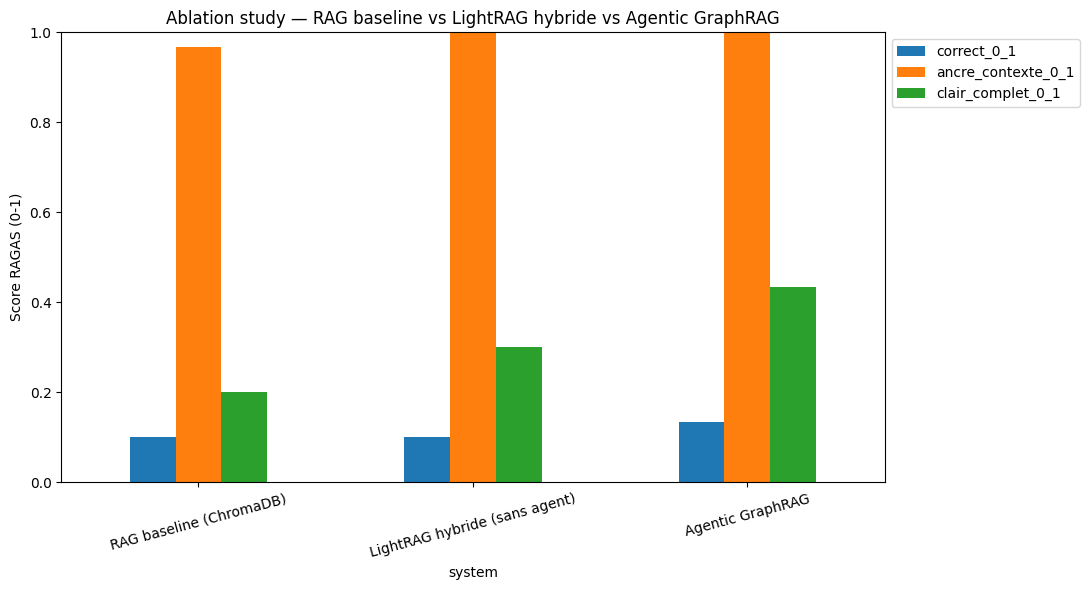

✓ figures/evaluation/fig15_ablation_study_comparaison.png


In [13]:
ax = comparison_table[METRICS].plot(kind="bar", figsize=(11, 6), rot=15)
ax.set_ylabel("Score RAGAS (0-1)")
ax.set_title("Ablation study — RAG baseline vs LightRAG hybride vs Agentic GraphRAG")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()

Path("figures").mkdir(parents=True, exist_ok=True)
plt.savefig("figures/evaluation/fig15_ablation_study_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ figures/evaluation/fig15_ablation_study_comparaison.png")

## 8. Paramètres utilisés par système

In [14]:
judge_desc = (
    f"Groq {graph_v3.GROQ_JUDGE_MODEL} (indépendant)"
    if graph_v3.USE_GROQ_JUDGE and graph_v3.GROQ_API_KEY
    else f"Ollama {graph_v3.JUDGE_MODEL_NAME} (indépendant)"
)

params_table = pd.DataFrame([
    {
        "Système": "RAG baseline (ChromaDB)",
        "Backend retrieval": f"ChromaDB — {CHROMA_DIR}",
        "Corpus indexé": f"{_vectorstore._collection.count()} chunks (nomic-embed-text, chunk_size=900, overlap=120, 500 documents)",
        "Paramètres retrieval": f"top_k={TOP_K_VECTOR}",
        "Générateur": GENERATOR_DESC,
        "Boucle agentique": "Non",
    },
    {
        "Système": "LightRAG hybride (sans agent)",
        "Backend retrieval": f"LightRAG — {graph_v3.INDEX_DIR} (post-traité : fusion entités + arêtes de co-occurrence)",
        "Corpus indexé": "4945 nœuds / 5593 relations (après post-traitement du 22/07/2026)",
        "Paramètres retrieval": f"mode=hybrid, top_k={graph_v3.TOP_K_LIGHTRAG}, chunk_top_k={graph_v3.CHUNK_TOP_K}, enable_rerank=False",
        "Générateur": GENERATOR_DESC,
        "Boucle agentique": "Non (1 seul appel de génération)",
    },
    {
        "Système": "Agentic GraphRAG",
        "Backend retrieval": f"LightRAG — {graph_v3.INDEX_DIR} (identique au système 2)",
        "Corpus indexé": "4945 nœuds / 5593 relations (identique au système 2)",
        "Paramètres retrieval": f"mode=hybrid, top_k={graph_v3.TOP_K_LIGHTRAG}, chunk_top_k={graph_v3.CHUNK_TOP_K}, enable_rerank=False",
        "Générateur": GENERATOR_DESC,
        "Boucle agentique": f"Oui — juge={judge_desc}, seuil_critique={graph_v3.CRITIQUE_SEUIL}, max_iterations={graph_v3.MAX_ITERATIONS}",
    },
])

display(params_table)
params_table.to_csv("Eval_agentic/ablation_study/ablation_study_parametres.csv", index=False)
print("✓ Eval_agentic/ablation_study/ablation_study_parametres.csv")

,Système,Backend retrieval,Corpus indexé,Paramètres retrieval,Générateur,Boucle agentique
0,RAG baseline (ChromaDB),ChromaDB — indexes/chroma_pfe500_baseline,"1587 chunks (nomic-embed-text, chunk_size=900, overlap=120, 500 documents)",top_k=5,Groq llama-3.1-8b-instant,Non
1,LightRAG hybride (sans agent),LightRAG — indexes\lightrag_500_connected_v2 (post-traité : fusion entités + arêtes de co-occurrence),4945 nœuds / 5593 relations (après post-traitement du 22/07/2026),"mode=hybrid, top_k=15, chunk_top_k=10, enable_rerank=False",Groq llama-3.1-8b-instant,Non (1 seul appel de génération)
2,Agentic GraphRAG,LightRAG — indexes\lightrag_500_connected_v2 (identique au système 2),4945 nœuds / 5593 relations (identique au système 2),"mode=hybrid, top_k=15, chunk_top_k=10, enable_rerank=False",Groq llama-3.1-8b-instant,"Oui — juge=Groq llama-3.3-70b-versatile (indépendant), seuil_critique=0.75, max_iterations=3"


✓ Eval_agentic/ablation_study/ablation_study_parametres.csv


## 9. Limites et discussion

In [26]:
best_system = comparison_table[METRICS].mean(axis=1).idxmax()
delta_vs_baseline = (comparison_table.loc["Agentic GraphRAG", METRICS] - comparison_table.loc["RAG baseline (ChromaDB)", METRICS]).round(3)
delta_vs_lightrag = (comparison_table.loc["Agentic GraphRAG", METRICS] - comparison_table.loc["LightRAG hybride (sans agent)", METRICS]).round(3)

print("=== Lecture automatique des résultats obtenus (calculée, pas supposée) ===\n")
print(f"Générateur utilisé pour les 3 systèmes : {GENERATOR_DESC}\n")
print(f"Système avec la moyenne RAGAS la plus élevée : {best_system}\n")
print("Delta Agentic GraphRAG - RAG baseline :")
print(delta_vs_baseline.to_string())
print("\nDelta Agentic GraphRAG - LightRAG hybride (sans agent) :")
print(delta_vs_lightrag.to_string())
print(f"\nTaille moyenne du contexte (système 2/3, LightRAG) : {df_details_lightrag['context_chars'].mean():.0f} caractères (max={df_details_lightrag['context_chars'].max()})")
print(f"Taille moyenne du contexte (système 1, ChromaDB)   : {df_details_baseline['context_chars'].mean():.0f} caractères (max={df_details_baseline['context_chars'].max()})")
if not (graph_v3.USE_NVIDIA and graph_v3.NVIDIA_API_KEY) and not (graph_v3.USE_GROQ and graph_v3.GROQ_API_KEY):
    print(f"Fenêtre de contexte du générateur local (num_ctx) : {graph_v3.OLLAMA_NUM_CTX} tokens — "
          f"à comparer à la taille de contexte mesurée ci-dessus")
print("""
Interprétation selon le résultat réel ci-dessus :
- Si les deltas sont POSITIFS sur les 4 métriques : la boucle agentique (critique
  + self-correct) apporte un gain mesurable au-delà du graphe seul -> résultat
  à mettre en avant tel quel dans le mémoire.
- Si LightRAG seul égale ou dépasse l'Agentic sur certaines métriques : cela
  peut s'expliquer par la taille limitée du corpus (500 documents) qui laisse
  peu de marge au SELF_CORRECT pour retrouver un meilleur contexte -> à
  documenter comme limite du corpus, pas de l'architecture.
- Si les 3 systèmes sont proches : le goulot d'étranglement est probablement
  le retrieval / la qualité du graphe plutôt que la couche agentique -> cf.
  discussion ci-dessous.
""")

=== Lecture automatique des résultats obtenus (calculée, pas supposée) ===

Générateur utilisé pour les 3 systèmes : Groq llama-3.1-8b-instant

Système avec la moyenne RAGAS la plus élevée : LightRAG hybride (sans agent)

Delta Agentic GraphRAG - RAG baseline :
correct_0_1           0.2
ancre_contexte_0_1   -0.3
clair_complet_0_1     0.3

Delta Agentic GraphRAG - LightRAG hybride (sans agent) :
correct_0_1          -0.1
ancre_contexte_0_1   -0.1
clair_complet_0_1    -0.2

Taille moyenne du contexte (système 2/3, LightRAG) : 30062 caractères (max=39719)
Taille moyenne du contexte (système 1, ChromaDB)   : 2994 caractères (max=3664)

Interprétation selon le résultat réel ci-dessus :
- Si les deltas sont POSITIFS sur les 4 métriques : la boucle agentique (critique
  + self-correct) apporte un gain mesurable au-delà du graphe seul -> résultat
  à mettre en avant tel quel dans le mémoire.
- Si LightRAG seul égale ou dépasse l'Agentic sur certaines métriques : cela
  peut s'expliquer par la 

### Limites identifiées

**Indexation et qualité du graphe**
- Le graphe LightRAG a été post-traité (fusion de 103 clusters de doublons, ajout de 498 arêtes de co-occurrence) mais reste **peu dense** : densité 0.00046, degré moyen 2.26, composante géante à 55.3 % des nœuds seulement (contre 43.3 % avant post-traitement). Une partie des questions peut donc rester sans chemin de graphe direct entre les entités concernées, même après amélioration.
- Le corpus indexé (500 résumés arXiv en cs.AI) est **volontairement restreint** bien adapté à un PFE mais trop petit pour que l'avantage du multi-hop agentique se manifeste pleinement (peu de chaînes de raisonnement alternatives disponibles en cas de premier échec).

**Benchmark et évaluation**
- Échantillon de 20 questions tirées des 76 questions vrai multi-hop validées par contenu (sur 340 candidates initiales)  suffisant pour dégager une tendance.


**Modèle et infrastructure**
- Le générateur effectivement utilisé (affiché en section 2 et à la cellule précédente) a sa propre limite de fenêtre de contexte ; si le contexte fusionné mesuré ci-dessus s'en approche ou la dépasse, cela peut dégrader Faithfulness indépendamment de la qualité du retrieval lui-même.
- Le juge RAGAS (métriques Faithfulness/Context Precision/Context Recall) utilise le même modèle pour les trois systèmes  cohérent pour la comparaison relative entre systèmes, mais signifie que les scores absolus dépendent aussi des capacités de jugement propres à ce modèle.

**Ce que cette étude démontre malgré ces limites**
Le protocole isole correctement la variable étudiée : système 2 et système 3 partagent strictement le même retrieval (même index, mêmes paramètres, mêmes appels) et le même générateur , toute différence entre les deux résultats est donc attribuable à la boucle agentique (critique + self-correction), et non à un effet de retrieval ou de modèle confondu.